In [168]:
# Customer Churn Prediction using Machine Learning

## Objective
#To build and evaluate machine learning models for predicting customer churn using the IBM Telco Customer Churn dataset.

In [169]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

import warnings
warnings.filterwarnings('ignore')

In [170]:
df = pd.read_csv(
    r"C:\Users\moham\ALFIDO_TECH\TASK1-Classification\dataset\ChurnDataset.csv"
)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [171]:
df.shape

(7043, 21)

In [172]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [173]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [174]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [175]:
#datacleaning
df.drop('customerID', axis=1, inplace=True)

df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

df['TotalCharges'] = df['TotalCharges'].fillna(
    df['TotalCharges'].median()
)

df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

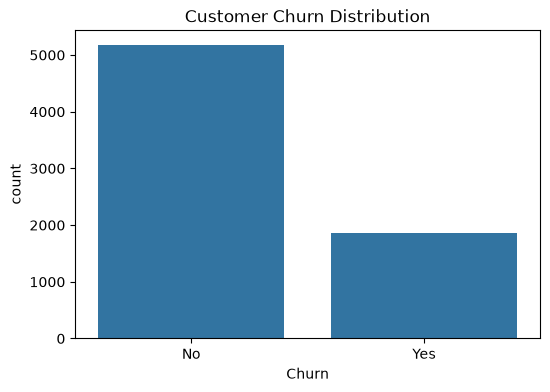

In [176]:
#churn distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df)
plt.title('Customer Churn Distribution')
plt.show()

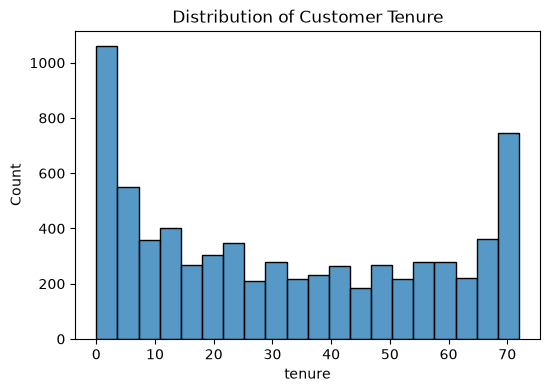

In [177]:
#histogram
plt.figure(figsize=(6,4))
sns.histplot(df['tenure'], bins=20)
plt.title('Distribution of Customer Tenure')
plt.show()

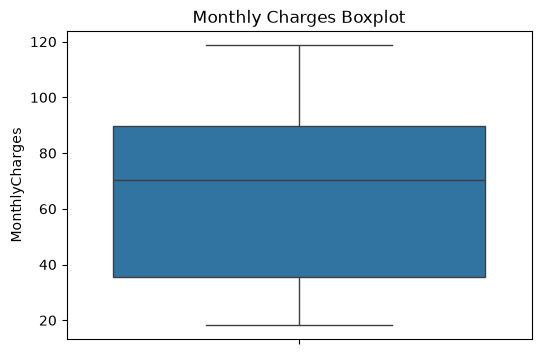

In [178]:
#boxplotting
plt.figure(figsize=(6,4))
sns.boxplot(y=df['MonthlyCharges'])
plt.title('Monthly Charges Boxplot')
plt.show()

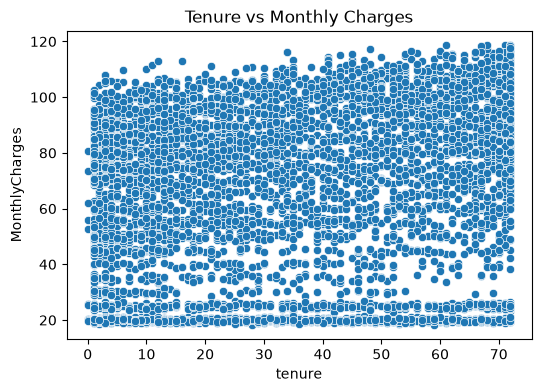

In [179]:
#scatter plot
plt.figure(figsize=(6,4))
sns.scatterplot(
    x='tenure',
    y='MonthlyCharges',
    data=df
)
plt.title('Tenure vs Monthly Charges')
plt.show()

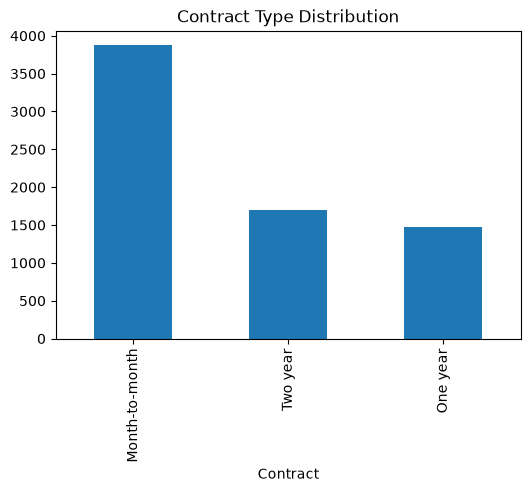

In [180]:
#barplot
plt.figure(figsize=(6,4))
df['Contract'].value_counts().plot(kind='bar')
plt.title('Contract Type Distribution')
plt.show()

In [181]:
#encoding categorical variables..
categorical_cols = df.select_dtypes(
    include=['object', 'string']
).columns

le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


In [182]:
#verifying
print(df.select_dtypes(include=['object', 'string']).columns)

Index([], dtype='str')


In [183]:
#feature selection 
X = df.drop('Churn', axis=1)
y = df['Churn']

In [184]:
#train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [185]:
#logistic regression
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_prob = lr.predict_proba(X_test)[:,1]

In [186]:
#random forest
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_prob = rf.predict_proba(X_test)[:,1]

In [187]:
#model evaluation
def evaluate_model(name, y_true, pred, prob):

    print(f"\n{name}")
    print("-"*30)

    print("Accuracy :", accuracy_score(y_true, pred))
    print("Precision:", precision_score(y_true, pred))
    print("Recall   :", recall_score(y_true, pred))
    print("F1 Score :", f1_score(y_true, pred))
    print("ROC-AUC  :", roc_auc_score(y_true, prob))

In [188]:
evaluate_model(
    "Logistic Regression",
    y_test,
    lr_pred,
    lr_prob
)

evaluate_model(
    "Random Forest",
    y_test,
    rf_pred,
    rf_prob
)


Logistic Regression
------------------------------
Accuracy : 0.8161816891412349
Precision: 0.6792452830188679
Recall   : 0.579088471849866
F1 Score : 0.6251808972503617
ROC-AUC  : 0.861530479157825

Random Forest
------------------------------
Accuracy : 0.7955997161107168
Precision: 0.6591760299625468
Recall   : 0.4718498659517426
F1 Score : 0.55
ROC-AUC  : 0.8369592783131656


In [189]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Logistic Regression Metrics
lr_pred = lr.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_pred)
lr_precision = precision_score(y_test, lr_pred)
lr_recall = recall_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred)
lr_auc = roc_auc_score(y_test, lr.predict_proba(X_test)[:, 1])

# Random Forest Metrics
rf_pred = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])

In [190]:
#CROSS-VALIDATION
cv_scores = cross_val_score(
    lr,
    X,
    y,
    cv=5,
    scoring='accuracy'
)
print("Cross Validation Scores:")
print(cv_scores)
print("\nAverage CV Accuracy:")
print(cv_scores.mean())

Cross Validation Scores:
[0.80624556 0.81121363 0.78566359 0.80752841 0.8046875 ]

Average CV Accuracy:
0.8030677382411768


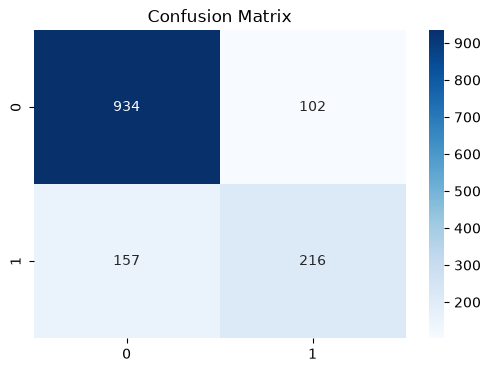

In [191]:
#confusion matrix
cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.show()

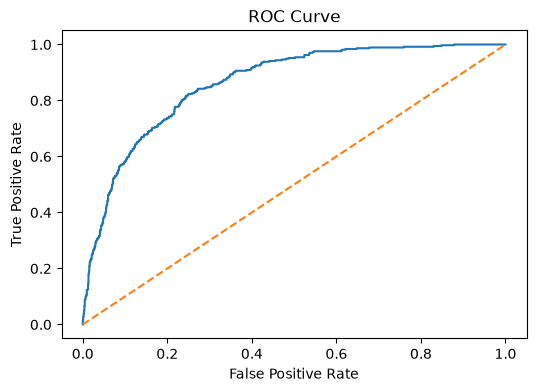

In [192]:
#ROC-CURVE
fpr, tpr, thresholds = roc_curve(
    y_test,
    lr_prob
)

plt.figure(figsize=(6,4))

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.show()

In [193]:
#classification report
print(classification_report(
    y_test,
    lr_pred
))

              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.58      0.63       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.75      1409
weighted avg       0.81      0.82      0.81      1409



In [ ]:
# Save the trained Logistic Regression model for future deployment
import os
import pickle

os.makedirs(
    r"C:\Users\moham\ALFIDO_TECH\TASK1-Classification\model",
    exist_ok=True
)

with open(
    r"C:\Users\moham\ALFIDO_TECH\TASK1-Classification\model\churn_model.pkl",
    "wb"
) as file:
    pickle.dump(lr, file)

print("Model Saved Successfully")

Model Saved Successfully


In [195]:
# Select 5 customers from the test set
sample_data = X_test.iloc[:5]

# Predict class (0 = No Churn, 1 = Churn)
predictions = lr.predict(sample_data)

# Predict probabilities
probabilities = lr.predict_proba(sample_data)

# Display results
for i in range(len(sample_data)):
    print(f"Customer {i+1}")
    print("-" * 30)

    print("Prediction:",
          "Churn" if predictions[i] == 1 else "No Churn")

    print(f"Probability of No Churn : {probabilities[i][0]:.2%}")
    print(f"Probability of Churn    : {probabilities[i][1]:.2%}")

    print()

Customer 1
------------------------------
Prediction: Churn
Probability of No Churn : 34.82%
Probability of Churn    : 65.18%

Customer 2
------------------------------
Prediction: No Churn
Probability of No Churn : 94.24%
Probability of Churn    : 5.76%

Customer 3
------------------------------
Prediction: No Churn
Probability of No Churn : 99.53%
Probability of Churn    : 0.47%

Customer 4
------------------------------
Prediction: Churn
Probability of No Churn : 42.05%
Probability of Churn    : 57.95%

Customer 5
------------------------------
Prediction: No Churn
Probability of No Churn : 99.44%
Probability of Churn    : 0.56%



In [198]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [lr_accuracy, rf_accuracy],
    "Precision": [lr_precision, rf_precision],
    "Recall": [lr_recall, rf_recall],
    "F1 Score": [lr_f1, rf_f1],
    "ROC-AUC": [lr_auc, rf_auc]
})

comparison = comparison.round(4)

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8162,0.6792,0.5791,0.6252,0.8615
1,Random Forest,0.7956,0.6592,0.4718,0.5500,0.8370


In [200]:
best_model = comparison.loc[
    comparison["Accuracy"].idxmax(), "Model"
]

print(f"Best Performing Model: {best_model}")

Best Performing Model: Logistic Regression


In [ ]:
# Conclusion

This project successfully developed a Customer Churn Prediction system using supervised machine learning.

The dataset was cleaned, preprocessed and encoded before training multiple classification models.

Logistic Regression and Random Forest were evaluated using Accuracy, Precision, Recall, F1-Score and ROC-AUC.

Among the evaluated models, Logistic Regression achieved the best overall performance and was selected as the final model.

SHAP Explainability was used to interpret predictions and identify the features that contribute most to customer churn.

Finally, the trained model was saved for deployment and tested on sample customer records by predicting both the churn class and the probability of churn.

This project demonstrates an end-to-end machine learning workflow from data preprocessing to model deployment readiness.